# Embedding Architecture Comparison
### Portfolio Transformer with Four Feature Encoding Variants

This notebook implements the Stage 1 architecture described in the dissertation proposal. Each encoding variant is trained in its own cell, with model weights and evaluation metrics saved to disk after completion. The final cells load all saved results for comparison and portfolio simulation. This structure ensures that completed variants are preserved if the kernel is restarted or a subsequent variant encounters an error.

In [ ]:
import gc
import json
import math
import sys
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
	print(f"GPU: {torch.cuda.get_device_name(0)}")
	print(f"CUDA version: {torch.version.cuda}")

Device: cuda
GPU: NVIDIA GeForce RTX 2080 Super with Max-Q Design
CUDA version: 13.0


## 1. Configuration

In [2]:
@dataclass
class Config:
	train_path: Path = Path("../data/processed/train.parquet")
	val_path: Path = Path("../data/processed/val.parquet")
	test_path: Path = Path("../data/processed/test.parquet")
	results_dir: Path = Path("../results")

	d_model: int = 64
	n_heads: int = 4
	n_layers: int = 2
	d_ff: int = 128
	dropout: float = 0.1

	top_k_attention: int = 50
	time2vec_dim: int = 16
	ple_num_bins: int = 16
	periodic_num_freq: int = 32

	learning_rate: float = 1e-4
	weight_decay: float = 1e-5
	max_epochs: int = 50
	patience: int = 7
	grad_clip: float = 1.0

	lambda_3m: float = 0.2
	lambda_6m: float = 0.5
	lambda_12m: float = 0.3

	n_classes: int = 5
	encoding_variant: str = "linear"
	max_firms: int = 5000
	seed: int = 24

cfg = Config()
cfg.results_dir.mkdir(parents = True, exist_ok = True)

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
if torch.cuda.is_available():
	torch.cuda.manual_seed_all(cfg.seed)

## 2. Column Classification

In [3]:
with open("../jsons/train_columns.json", "r") as f:
	all_columns = json.load(f)

miss_flags = [c for c in all_columns if c.endswith("_miss")]
miss_bases = [c.replace("_miss", "") for c in miss_flags]
non_miss = [c for c in all_columns if not c.endswith("_miss")]

lag12_cols = [c for c in non_miss if c.endswith("_lag12")]
lag12_bases = [c.replace("_lag12", "") for c in lag12_cols]

K1_CHARS = sorted([c for c in lag12_bases if c in non_miss])
all_chars = sorted([c for c in miss_bases if c in non_miss])
K0_CHARS = sorted([c for c in all_chars if c not in K1_CHARS])

LAG_SUFFIXES = ["", "_lag12", "_lag24", "_lag36", "_lag48", "_lag60"]
LAG_POSITIONS = [0, 12, 24, 36, 48, 60]

k0_feature_cols = K0_CHARS.copy()
k1_feature_cols = []
for char in K1_CHARS:
	for suffix in LAG_SUFFIXES:
		k1_feature_cols.append(char + suffix)

target_cols = ["target_3m", "target_6m", "target_12m"]

print(f"K0 characteristics (current only): {len(K0_CHARS)}")
print(f"K1 characteristics (with lags): {len(K1_CHARS)}")
print(f"K1 feature columns (K1 x 6 lags): {len(k1_feature_cols)}")
print(f"Missingness flags: {len(miss_flags)}")
print(f"Total model input features: {len(k0_feature_cols) + len(k1_feature_cols) + len(miss_flags)}")

K0 characteristics (current only): 55
K1 characteristics (with lags): 97
K1 feature columns (K1 x 6 lags): 582
Missingness flags: 152
Total model input features: 789


## 3. Dataset and Data Loading

In [4]:
class CrossSectionalDataset(Dataset):
	"""
	Dataset that groups firm observations by month for cross-sectional attention.
	Each item returned is an entire cross-section (all firms in one month).
	"""

	def __init__(self, df, k0_cols, k1_cols, miss_cols, target_cols, n_classes, max_firms):
		self.n_classes = n_classes
		self.max_firms = max_firms
		self.target_col_names = target_cols

		dates = sorted(df["eom"].unique())
		self.monthly_data = []

		n_k1 = len(K1_CHARS)
		for date in dates:
			group = df[df["eom"] == date]
			if len(group) > max_firms:
				group = group.sample(n = max_firms, random_state = 42)

			k0 = torch.tensor(group[k0_cols].values, dtype = torch.float32)
			k1_raw = group[k1_cols].values.astype(np.float32)
			k1 = torch.tensor(k1_raw.reshape(len(group), n_k1, 6), dtype = torch.float32)
			miss = torch.tensor(group[miss_cols].values, dtype = torch.float32)

			# Discretised quintile labels for training
			targets = {}
			# Raw continuous returns for portfolio simulation
			raw_targets = {}
			for tc in target_cols:
				vals = group[tc].values.copy()
				valid_mask = ~np.isnan(vals)

				labels = np.full(len(vals), -1, dtype = np.int64)
				if valid_mask.sum() > n_classes:
					breaks = np.quantile(
						vals[valid_mask],
						np.linspace(0, 1, n_classes + 1)[1:-1]
					)
					labels[valid_mask] = np.digitize(vals[valid_mask], breaks)
				targets[tc] = torch.tensor(labels, dtype = torch.long)

				raw_vals = np.copy(vals)
				raw_vals[~valid_mask] = 0.0
				raw_targets[tc] = torch.tensor(raw_vals, dtype = torch.float32)

			self.monthly_data.append({
				"k0": k0,
				"k1": k1,
				"miss": miss,
				"targets": targets,
				"raw_targets": raw_targets,
				"n_firms": len(group),
			})

		del df
		gc.collect()

	def __len__(self):
		return len(self.monthly_data)

	def __getitem__(self, idx):
		return self.monthly_data[idx]


def load_split(path, k0_cols, k1_cols, miss_cols, target_cols, n_classes, max_firms):
	"""Load only the required columns from a parquet file and construct the dataset."""
	required = k0_cols + k1_cols + miss_cols + target_cols + ["eom"]
	df = pd.read_parquet(path, columns = required)

	for col in k0_cols + k1_cols + miss_cols:
		df[col] = df[col].fillna(0.0)

	return CrossSectionalDataset(df, k0_cols, k1_cols, miss_cols, target_cols, n_classes, max_firms)

## 4. Model Components

### 4.1 Time2Vec Temporal Encoding

In [5]:
class Time2Vec(nn.Module):
	def __init__(self, d_out):
		super().__init__()
		self.d_out = d_out
		self.omega = nn.Parameter(torch.randn(d_out))
		self.phi = nn.Parameter(torch.randn(d_out))

	def forward(self, lag_position):
		lag = lag_position.float().unsqueeze(-1)
		raw = self.omega * lag + self.phi
		out = torch.zeros_like(raw)
		out[..., 0] = raw[..., 0]
		out[..., 1:] = torch.sin(raw[..., 1:])
		return out

### 4.2 Gated Residual Network

In [6]:
class GRN(nn.Module):
	def __init__(self, d_model, d_ff, dropout = 0.1):
		super().__init__()
		self.fc1 = nn.Linear(d_model, d_ff)
		self.fc2 = nn.Linear(d_ff, d_model * 2)
		self.layer_norm = nn.LayerNorm(d_model)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x):
		residual = x
		h = F.elu(self.fc1(x))
		h = self.dropout(h)
		gated = self.fc2(h)
		value, gate = gated.chunk(2, dim = -1)
		h = value * torch.sigmoid(gate)
		return self.layer_norm(residual + h)

### 4.3 Feature Encoding Variants

In [7]:
class LinearEncoder(nn.Module):
	def __init__(self, n_features, d_model):
		super().__init__()
		self.weights = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
		self.biases = nn.Parameter(torch.zeros(n_features, d_model))

	def forward(self, x):
		return x.unsqueeze(-1) * self.weights.unsqueeze(0) + self.biases.unsqueeze(0)


class PerFeatureTokeniser(nn.Module):
	def __init__(self, n_features, d_model):
		super().__init__()
		self.projections = nn.Parameter(torch.randn(n_features, 1, d_model) * 0.02)
		self.biases = nn.Parameter(torch.zeros(n_features, d_model))

	def forward(self, x):
		x_exp = x.unsqueeze(-1)
		proj = self.projections.squeeze(1).unsqueeze(0)
		return x_exp * proj + self.biases.unsqueeze(0)


class PiecewiseLinearEncoder(nn.Module):
	def __init__(self, n_features, d_model, num_bins = 16):
		super().__init__()
		self.num_bins = num_bins
		boundaries = torch.linspace(-0.5, 0.5, num_bins + 1)
		self.register_buffer("boundaries", boundaries)
		self.feature_weights = nn.Parameter(torch.randn(n_features, num_bins, d_model) * 0.02)

	def _encode_bins(self, x):
		t_lower = self.boundaries[:-1]
		t_upper = self.boundaries[1:]
		x_exp = x.unsqueeze(-1)
		activations = torch.clamp((x_exp - t_lower) / (t_upper - t_lower + 1e-8), 0.0, 1.0)
		return activations

	def forward(self, x):
		bin_act = self._encode_bins(x)
		out = torch.einsum("bnk,nkd->bnd", bin_act, self.feature_weights)
		return out


class PeriodicEncoder(nn.Module):
	def __init__(self, n_features, d_model, num_freq = 32):
		super().__init__()
		self.num_freq = num_freq
		self.omega = nn.Parameter(torch.randn(n_features, num_freq) * 0.1)
		self.phi = nn.Parameter(torch.randn(n_features, num_freq) * 0.1)
		self.proj = nn.Linear(num_freq, d_model)

	def forward(self, x):
		x_exp = x.unsqueeze(-1)
		sinusoidal = torch.sin(x_exp * self.omega.unsqueeze(0) + self.phi.unsqueeze(0))
		out = self.proj(sinusoidal)
		return out


def build_encoder(variant, n_features, d_model, ple_bins = 16, periodic_freq = 32):
	if variant == "linear":
		return LinearEncoder(n_features, d_model)
	elif variant == "per_feature":
		return PerFeatureTokeniser(n_features, d_model)
	elif variant == "ple":
		return PiecewiseLinearEncoder(n_features, d_model, num_bins = ple_bins)
	elif variant == "periodic":
		return PeriodicEncoder(n_features, d_model, num_freq = periodic_freq)
	else:
		raise ValueError(f"Unknown encoding variant: {variant}")

### 4.4 Multi-Head Sparse Attention

In [8]:
class SparseMultiHeadAttention(nn.Module):
	def __init__(self, d_model, n_heads, top_k, dropout = 0.1):
		super().__init__()
		assert d_model % n_heads == 0
		self.d_model = d_model
		self.n_heads = n_heads
		self.d_k = d_model // n_heads
		self.top_k = top_k

		self.W_q = nn.Linear(d_model, d_model)
		self.W_k = nn.Linear(d_model, d_model)
		self.W_v = nn.Linear(d_model, d_model)
		self.W_o = nn.Linear(d_model, d_model)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x):
		n_firms = x.shape[0]
		x = x.unsqueeze(0)

		Q = self.W_q(x).view(1, n_firms, self.n_heads, self.d_k).transpose(1, 2)
		K = self.W_k(x).view(1, n_firms, self.n_heads, self.d_k).transpose(1, 2)
		V = self.W_v(x).view(1, n_firms, self.n_heads, self.d_k).transpose(1, 2)

		scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

		k = min(self.top_k, n_firms)
		topk_vals, _ = scores.topk(k, dim = -1)
		threshold = topk_vals[..., -1:].detach()
		mask = scores < threshold
		scores = scores.masked_fill(mask, float("-inf"))

		attn_weights = F.softmax(scores, dim = -1)
		attn_weights = self.dropout(attn_weights)

		context = torch.matmul(attn_weights, V)
		context = context.transpose(1, 2).contiguous().view(1, n_firms, self.d_model)
		out = self.W_o(context).squeeze(0)

		return out, attn_weights.squeeze(0)

### 4.5 Transformer Encoder Block

In [9]:
class TransformerBlock(nn.Module):
	def __init__(self, d_model, n_heads, d_ff, top_k, dropout = 0.1):
		super().__init__()
		self.norm1 = nn.LayerNorm(d_model)
		self.attention = SparseMultiHeadAttention(d_model, n_heads, top_k, dropout)
		self.grn = GRN(d_model, d_ff, dropout)

	def forward(self, x):
		normed = self.norm1(x)
		attn_out, attn_weights = self.attention(normed)
		x = x + attn_out
		x = self.grn(x)
		return x, attn_weights

### 4.6 Portfolio Transformer

In [10]:
class PortfolioTransformer(nn.Module):
	def __init__(self, config):
		super().__init__()
		self.config = config
		n_k0 = len(K0_CHARS)
		n_k1 = len(K1_CHARS)
		n_miss = len(miss_flags)

		self.k0_encoder = build_encoder(
			config.encoding_variant, n_k0, config.d_model,
			ple_bins = config.ple_num_bins,
			periodic_freq = config.periodic_num_freq
		)
		self.k1_encoder = build_encoder(
			config.encoding_variant, n_k1, config.d_model,
			ple_bins = config.ple_num_bins,
			periodic_freq = config.periodic_num_freq
		)

		self.time2vec = Time2Vec(config.d_model)
		self.k0_static_emb = nn.Parameter(torch.randn(n_k0, config.d_model) * 0.02)
		self.miss_proj = nn.Linear(n_miss, config.d_model)

		self.blocks = nn.ModuleList([
			TransformerBlock(
				config.d_model, config.n_heads, config.d_ff,
				config.top_k_attention, config.dropout
			)
			for _ in range(config.n_layers)
		])

		self.head_3m = nn.Sequential(nn.LayerNorm(config.d_model), nn.Linear(config.d_model, config.n_classes))
		self.head_6m = nn.Sequential(nn.LayerNorm(config.d_model), nn.Linear(config.d_model, config.n_classes))
		self.head_12m = nn.Sequential(nn.LayerNorm(config.d_model), nn.Linear(config.d_model, config.n_classes))

		self.register_buffer("lag_positions", torch.tensor(LAG_POSITIONS, dtype = torch.float32))

	def _encode_firm_token(self, k0, k1, miss):
		n_firms = k0.shape[0]

		k0_encoded = self.k0_encoder(k0) + self.k0_static_emb.unsqueeze(0)
		k0_token = k0_encoded.sum(dim = 1)

		k1_flat = k1.permute(0, 2, 1).reshape(n_firms * 6, -1)
		k1_encoded = self.k1_encoder(k1_flat)
		k1_encoded = k1_encoded.view(n_firms, 6, len(K1_CHARS), self.config.d_model)

		t2v_all = self.time2vec(self.lag_positions).unsqueeze(0).unsqueeze(2)
		k1_encoded = k1_encoded + t2v_all

		k1_token = k1_encoded.sum(dim = (1, 2))

		miss_token = self.miss_proj(miss)
		return k0_token + k1_token + miss_token

	def forward(self, k0, k1, miss):
		z = self._encode_firm_token(k0, k1, miss)

		all_attn = []
		for block in self.blocks:
			z, attn_w = block(z)
			all_attn.append(attn_w)

		return self.head_3m(z), self.head_6m(z), self.head_12m(z), all_attn

## 5. Training Utilities

In [11]:
def compute_multitask_loss(logits_3m, logits_6m, logits_12m, targets, config):
	total_loss = torch.tensor(0.0, device = logits_3m.device)
	horizon_losses = {}

	for horizon, logits, weight in [
		("target_3m", logits_3m, config.lambda_3m),
		("target_6m", logits_6m, config.lambda_6m),
		("target_12m", logits_12m, config.lambda_12m),
	]:
		labels = targets[horizon]
		valid = labels >= 0
		if valid.sum() > 0:
			loss = F.cross_entropy(logits[valid], labels[valid])
			total_loss = total_loss + weight * loss
			horizon_losses[horizon] = loss.item()

	return total_loss, horizon_losses


def compute_accuracy(logits, labels):
	valid = labels >= 0
	if valid.sum() == 0:
		return 0.0
	preds = logits[valid].argmax(dim = -1)
	return (preds == labels[valid]).float().mean().item()


def compute_rank_correlation(logits, labels):
	valid = labels >= 0
	if valid.sum() < 10:
		return 0.0
	probs = F.softmax(logits[valid], dim = -1)
	quintile_idx = torch.arange(probs.shape[1], device = probs.device, dtype = torch.float32)
	expected_score = (probs * quintile_idx.unsqueeze(0)).sum(dim = -1)

	def _rank(t):
		order = t.argsort()
		ranks = torch.zeros_like(t)
		ranks[order] = torch.arange(len(t), device = t.device, dtype = torch.float32)
		return ranks

	rank_pred = _rank(expected_score)
	rank_true = _rank(labels[valid].float())
	mean_p = rank_pred.mean()
	mean_t = rank_true.mean()
	cov = ((rank_pred - mean_p) * (rank_true - mean_t)).sum()
	std_p = ((rank_pred - mean_p) ** 2).sum().sqrt()
	std_t = ((rank_true - mean_t) ** 2).sum().sqrt()
	if std_p * std_t < 1e-8:
		return 0.0
	return (cov / (std_p * std_t)).item()

## 6. Training and Persistence

In [12]:
def train_one_epoch(model, dataset, optimizer, config):
	model.train()
	epoch_loss = 0.0
	n_months = 0
	scaler = torch.amp.GradScaler("cuda")

	indices = np.random.permutation(len(dataset))
	for idx in indices:
		batch = dataset[idx]
		k0 = batch["k0"].to(device, non_blocking = True)
		k1 = batch["k1"].to(device, non_blocking = True)
		miss = batch["miss"].to(device, non_blocking = True)
		targets = {k: v.to(device, non_blocking = True) for k, v in batch["targets"].items()}

		optimizer.zero_grad(set_to_none = True)
		with torch.amp.autocast("cuda"):
			logits_3m, logits_6m, logits_12m, _ = model(k0, k1, miss)
			loss, _ = compute_multitask_loss(logits_3m, logits_6m, logits_12m, targets, config)

		if loss.requires_grad:
			scaler.scale(loss).backward()
			scaler.unscale_(optimizer)
			torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
			scaler.step(optimizer)
			scaler.update()

		epoch_loss += loss.item()
		n_months += 1

	return epoch_loss / max(n_months, 1)


@torch.no_grad()
def evaluate(model, dataset, config):
	model.eval()
	total_loss = 0.0
	total_corr = {"target_3m": 0.0, "target_6m": 0.0, "target_12m": 0.0}
	total_acc = {"target_3m": 0.0, "target_6m": 0.0, "target_12m": 0.0}
	n_months = 0

	for idx in range(len(dataset)):
		batch = dataset[idx]
		k0 = batch["k0"].to(device)
		k1 = batch["k1"].to(device)
		miss = batch["miss"].to(device)
		targets = {k: v.to(device) for k, v in batch["targets"].items()}

		logits_3m, logits_6m, logits_12m, _ = model(k0, k1, miss)
		loss, _ = compute_multitask_loss(logits_3m, logits_6m, logits_12m, targets, config)
		total_loss += loss.item()

		for horizon, logits in [("target_3m", logits_3m), ("target_6m", logits_6m), ("target_12m", logits_12m)]:
			labels = targets[horizon]
			total_corr[horizon] += compute_rank_correlation(logits, labels)
			total_acc[horizon] += compute_accuracy(logits, labels)

		n_months += 1

	n = max(n_months, 1)
	return {
		"loss": total_loss / n,
		"rank_corr": {k: v / n for k, v in total_corr.items()},
		"accuracy": {k: v / n for k, v in total_acc.items()},
	}


def train_variant(config):
	"""
	Train a single encoding variant, evaluate on test, save weights and metrics to disk,
	then free all memory. Returns nothing. Results are loaded from disk later.
	"""
	variant = config.encoding_variant
	print(f"Encoding variant: {variant}")
	print(f"d_model: {config.d_model}, n_heads: {config.n_heads}, n_layers: {config.n_layers}")
	print(f"Horizon weights: 3m={config.lambda_3m}, 6m={config.lambda_6m}, 12m={config.lambda_12m}")
	print()

	# Load training and validation data
	train_ds = load_split(
		config.train_path, k0_feature_cols, k1_feature_cols,
		miss_flags, target_cols, config.n_classes, config.max_firms
	)
	val_ds = load_split(
		config.val_path, k0_feature_cols, k1_feature_cols,
		miss_flags, target_cols, config.n_classes, config.max_firms
	)
	print(f"Train months: {len(train_ds)}, Val months: {len(val_ds)}")

	# Initialise model
	model = PortfolioTransformer(config).to(device)
	n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
	print(f"Trainable parameters: {n_params:,}")
	print()

	optimizer = torch.optim.AdamW(
		model.parameters(),
		lr = config.learning_rate,
		weight_decay = config.weight_decay
	)
	scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
		optimizer, mode = "min", factor = 0.5, patience = 3
	)

	best_val_loss = float("inf")
	patience_counter = 0
	history = {"train_loss": [], "val_loss": [], "val_corr_6m": []}
	weights_path = config.results_dir / f"weights_{variant}.pt"

	for epoch in range(1, config.max_epochs + 1):
		train_loss = train_one_epoch(model, train_ds, optimizer, config)
		val_metrics = evaluate(model, val_ds, config)
		val_loss = val_metrics["loss"]
		scheduler.step(val_loss)

		history["train_loss"].append(train_loss)
		history["val_loss"].append(val_loss)
		history["val_corr_6m"].append(val_metrics["rank_corr"]["target_6m"])

		current_lr = optimizer.param_groups[0]["lr"]
		print(
			f"Epoch {epoch:3d} | "
			f"Train Loss: {train_loss:.4f} | "
			f"Val Loss: {val_loss:.4f} | "
			f"Val Corr 6m: {val_metrics['rank_corr']['target_6m']:.4f} | "
			f"LR: {current_lr:.2e}"
		)
		sys.stdout.flush()

		if val_loss < best_val_loss - 1e-5:
			best_val_loss = val_loss
			patience_counter = 0
			torch.save(model.state_dict(), weights_path)
		else:
			patience_counter += 1
			if patience_counter >= config.patience:
				print(f"Early stopping at epoch {epoch}")
				break

	# Free training data
	del train_ds, val_ds
	gc.collect()

	# Load best weights and evaluate on test set
	model.load_state_dict(torch.load(weights_path, weights_only = True))
	test_ds = load_split(
		config.test_path, k0_feature_cols, k1_feature_cols,
		miss_flags, target_cols, config.n_classes, config.max_firms
	)
	test_metrics = evaluate(model, test_ds, config)
	del test_ds

	print(f"\nTest Loss: {test_metrics['loss']:.4f}")
	for h in ["target_3m", "target_6m", "target_12m"]:
		print(f"  {h} | Corr: {test_metrics['rank_corr'][h]:.4f} | Acc: {test_metrics['accuracy'][h]:.4f}")

	# Save history and test metrics to JSON
	results_path = config.results_dir / f"metrics_{variant}.json"
	results_payload = {
		"variant": variant,
		"n_params": n_params,
		"best_val_loss": best_val_loss,
		"stopped_epoch": len(history["train_loss"]),
		"history": history,
		"test_metrics": test_metrics,
	}
	with open(results_path, "w") as f:
		json.dump(results_payload, f, indent = 2)

	print(f"\nWeights saved to: {weights_path}")
	print(f"Metrics saved to: {results_path}")

	# Free everything
	del model
	gc.collect()
	if torch.cuda.is_available():
		torch.cuda.empty_cache()

## Hyperparameters Tuning

## 7. Train Each Variant

Each cell below trains a single encoding variant, saves its weights and metrics to the `results/` directory, and then frees all memory. Run them one at a time. If the kernel restarts, re-run cells 1 through 6 (definitions only, no training) and skip any variant that already has its files in `results/`.

### 7.1 Linear Projection

In [15]:
cfg.encoding_variant = "linear"
train_variant(cfg)

Encoding variant: linear
d_model: 64, n_heads: 4, n_layers: 2
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 117,711

Epoch   1 | Train Loss: 1.6205 | Val Loss: 1.6095 | Val Corr 6m: 0.0987 | LR: 1.00e-04
Epoch   2 | Train Loss: 1.6100 | Val Loss: 1.6094 | Val Corr 6m: 0.0962 | LR: 1.00e-04
Epoch   3 | Train Loss: 1.6098 | Val Loss: 1.6094 | Val Corr 6m: 0.0953 | LR: 1.00e-04
Epoch   4 | Train Loss: 1.6097 | Val Loss: 1.6094 | Val Corr 6m: 0.0944 | LR: 1.00e-04
Epoch   5 | Train Loss: 1.6096 | Val Loss: 1.6093 | Val Corr 6m: 0.0931 | LR: 1.00e-04
Epoch   6 | Train Loss: 1.6095 | Val Loss: 1.6092 | Val Corr 6m: 0.0916 | LR: 1.00e-04
Epoch   7 | Train Loss: 1.6094 | Val Loss: 1.6091 | Val Corr 6m: 0.0897 | LR: 1.00e-04
Epoch   8 | Train Loss: 1.6093 | Val Loss: 1.6090 | Val Corr 6m: 0.0858 | LR: 1.00e-04
Epoch   9 | Train Loss: 1.6091 | Val Loss: 1.6086 | Val Corr 6m: 0.0812 | LR: 1.00e-04
Epoch  10 | Train Loss: 1.6084 | Val Loss: 1.606

### 7.2 Per-Feature Tokenisation

In [16]:
cfg.encoding_variant = "per_feature"
train_variant(cfg)

Encoding variant: per_feature
d_model: 64, n_heads: 4, n_layers: 2
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 117,711

Epoch   1 | Train Loss: 1.6125 | Val Loss: 1.6090 | Val Corr 6m: 0.0913 | LR: 1.00e-04
Epoch   2 | Train Loss: 1.6091 | Val Loss: 1.6081 | Val Corr 6m: 0.0887 | LR: 1.00e-04
Epoch   3 | Train Loss: 1.6070 | Val Loss: 1.6025 | Val Corr 6m: 0.0830 | LR: 1.00e-04
Epoch   4 | Train Loss: 1.6009 | Val Loss: 1.5960 | Val Corr 6m: 0.0940 | LR: 1.00e-04
Epoch   5 | Train Loss: 1.5962 | Val Loss: 1.5926 | Val Corr 6m: 0.1110 | LR: 1.00e-04
Epoch   6 | Train Loss: 1.5925 | Val Loss: 1.5892 | Val Corr 6m: 0.1224 | LR: 1.00e-04
Epoch   7 | Train Loss: 1.5896 | Val Loss: 1.5856 | Val Corr 6m: 0.1289 | LR: 1.00e-04
Epoch   8 | Train Loss: 1.5870 | Val Loss: 1.5840 | Val Corr 6m: 0.1324 | LR: 1.00e-04
Epoch   9 | Train Loss: 1.5842 | Val Loss: 1.5791 | Val Corr 6m: 0.1353 | LR: 1.00e-04
Epoch  10 | Train Loss: 1.5821 | Val Loss: 

### 7.3 Piecewise Linear Encoding

In [17]:
cfg.encoding_variant = "ple"
train_variant(cfg)

Encoding variant: ple
d_model: 64, n_heads: 4, n_layers: 2
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 253,903

Epoch   1 | Train Loss: 1.6161 | Val Loss: 1.6082 | Val Corr 6m: 0.0929 | LR: 1.00e-04
Epoch   2 | Train Loss: 1.6073 | Val Loss: 1.6035 | Val Corr 6m: 0.0909 | LR: 1.00e-04
Epoch   3 | Train Loss: 1.5999 | Val Loss: 1.5937 | Val Corr 6m: 0.1005 | LR: 1.00e-04
Epoch   4 | Train Loss: 1.5927 | Val Loss: 1.5867 | Val Corr 6m: 0.1177 | LR: 1.00e-04
Epoch   5 | Train Loss: 1.5864 | Val Loss: 1.5789 | Val Corr 6m: 0.1308 | LR: 1.00e-04
Epoch   6 | Train Loss: 1.5809 | Val Loss: 1.5733 | Val Corr 6m: 0.1337 | LR: 1.00e-04
Epoch   7 | Train Loss: 1.5782 | Val Loss: 1.5703 | Val Corr 6m: 0.1358 | LR: 1.00e-04
Epoch   8 | Train Loss: 1.5765 | Val Loss: 1.5689 | Val Corr 6m: 0.1373 | LR: 1.00e-04
Epoch   9 | Train Loss: 1.5750 | Val Loss: 1.5677 | Val Corr 6m: 0.1396 | LR: 1.00e-04
Epoch  10 | Train Loss: 1.5739 | Val Loss: 1.5670 |

### 7.4 Periodic Encoding

In [18]:
cfg.encoding_variant = "periodic"
train_variant(cfg)

Encoding variant: periodic
d_model: 64, n_heads: 4, n_layers: 2
Horizon weights: 3m=0.2, 6m=0.5, 12m=0.3

Train months: 252, Val months: 60
Trainable parameters: 112,207

Epoch   1 | Train Loss: 1.6197 | Val Loss: 1.6094 | Val Corr 6m: 0.0827 | LR: 1.00e-04
Epoch   2 | Train Loss: 1.6101 | Val Loss: 1.6094 | Val Corr 6m: 0.0865 | LR: 1.00e-04
Epoch   3 | Train Loss: 1.6098 | Val Loss: 1.6093 | Val Corr 6m: 0.0834 | LR: 1.00e-04
Epoch   4 | Train Loss: 1.6096 | Val Loss: 1.6090 | Val Corr 6m: 0.0801 | LR: 1.00e-04
Epoch   5 | Train Loss: 1.6092 | Val Loss: 1.6082 | Val Corr 6m: 0.0769 | LR: 1.00e-04
Epoch   6 | Train Loss: 1.6072 | Val Loss: 1.6010 | Val Corr 6m: 0.0760 | LR: 1.00e-04
Epoch   7 | Train Loss: 1.5997 | Val Loss: 1.5953 | Val Corr 6m: 0.0921 | LR: 1.00e-04
Epoch   8 | Train Loss: 1.5944 | Val Loss: 1.5905 | Val Corr 6m: 0.1081 | LR: 1.00e-04
Epoch   9 | Train Loss: 1.5896 | Val Loss: 1.5860 | Val Corr 6m: 0.1190 | LR: 1.00e-04
Epoch  10 | Train Loss: 1.5868 | Val Loss: 1.5

## 8. Load Results and Compare Variants

In [19]:
def load_all_results(results_dir):
	"""Load saved metrics for all completed variants from disk."""
	variants = ["linear", "per_feature", "ple", "periodic"]
	all_results = {}

	for variant in variants:
		metrics_path = results_dir / f"metrics_{variant}.json"
		if metrics_path.exists():
			with open(metrics_path, "r") as f:
				all_results[variant] = json.load(f)
			print(f"Loaded: {variant} (stopped at epoch {all_results[variant]['stopped_epoch']})")
		else:
			print(f"Missing: {variant} (not yet trained)")

	return all_results


all_results = load_all_results(cfg.results_dir)

Loaded: linear (stopped at epoch 20)
Loaded: per_feature (stopped at epoch 37)
Loaded: ple (stopped at epoch 23)
Loaded: periodic (stopped at epoch 50)


## 9. Results Summary

In [20]:
def print_results_table(all_results):
	print(f"{'Variant':<18} {'Params':>10} {'Epoch':>6} {'Test Loss':>10} {'Corr 3m':>8} {'Corr 6m':>8} {'Corr 12m':>9} {'Acc 6m':>7}")
	print("=" * 88)

	for variant, res in all_results.items():
		tm = res["test_metrics"]
		print(
			f"{variant:<18} "
			f"{res['n_params']:>10,} "
			f"{res['stopped_epoch']:>6} "
			f"{tm['loss']:>10.4f} "
			f"{tm['rank_corr']['target_3m']:>8.4f} "
			f"{tm['rank_corr']['target_6m']:>8.4f} "
			f"{tm['rank_corr']['target_12m']:>9.4f} "
			f"{tm['accuracy']['target_6m']:>7.4f}"
		)

	# Identify best variant
	best = max(all_results, key = lambda v: all_results[v]["test_metrics"]["rank_corr"]["target_6m"])
	print(f"\nBest variant by 6m rank correlation: {best}")


print_results_table(all_results)

Variant                Params  Epoch  Test Loss  Corr 3m  Corr 6m  Corr 12m  Acc 6m
linear                117,711     20     1.4079   0.0530   0.0587    0.0648  0.2094
per_feature           117,711     37     1.3790   0.1005   0.1192    0.1313  0.2443
ple                   253,903     23     1.3748   0.0989   0.1182    0.1301  0.2470
periodic              112,207     50     1.3833   0.0957   0.1049    0.1150  0.2337

Best variant by 6m rank correlation: per_feature


## 10. Training Diagnostics

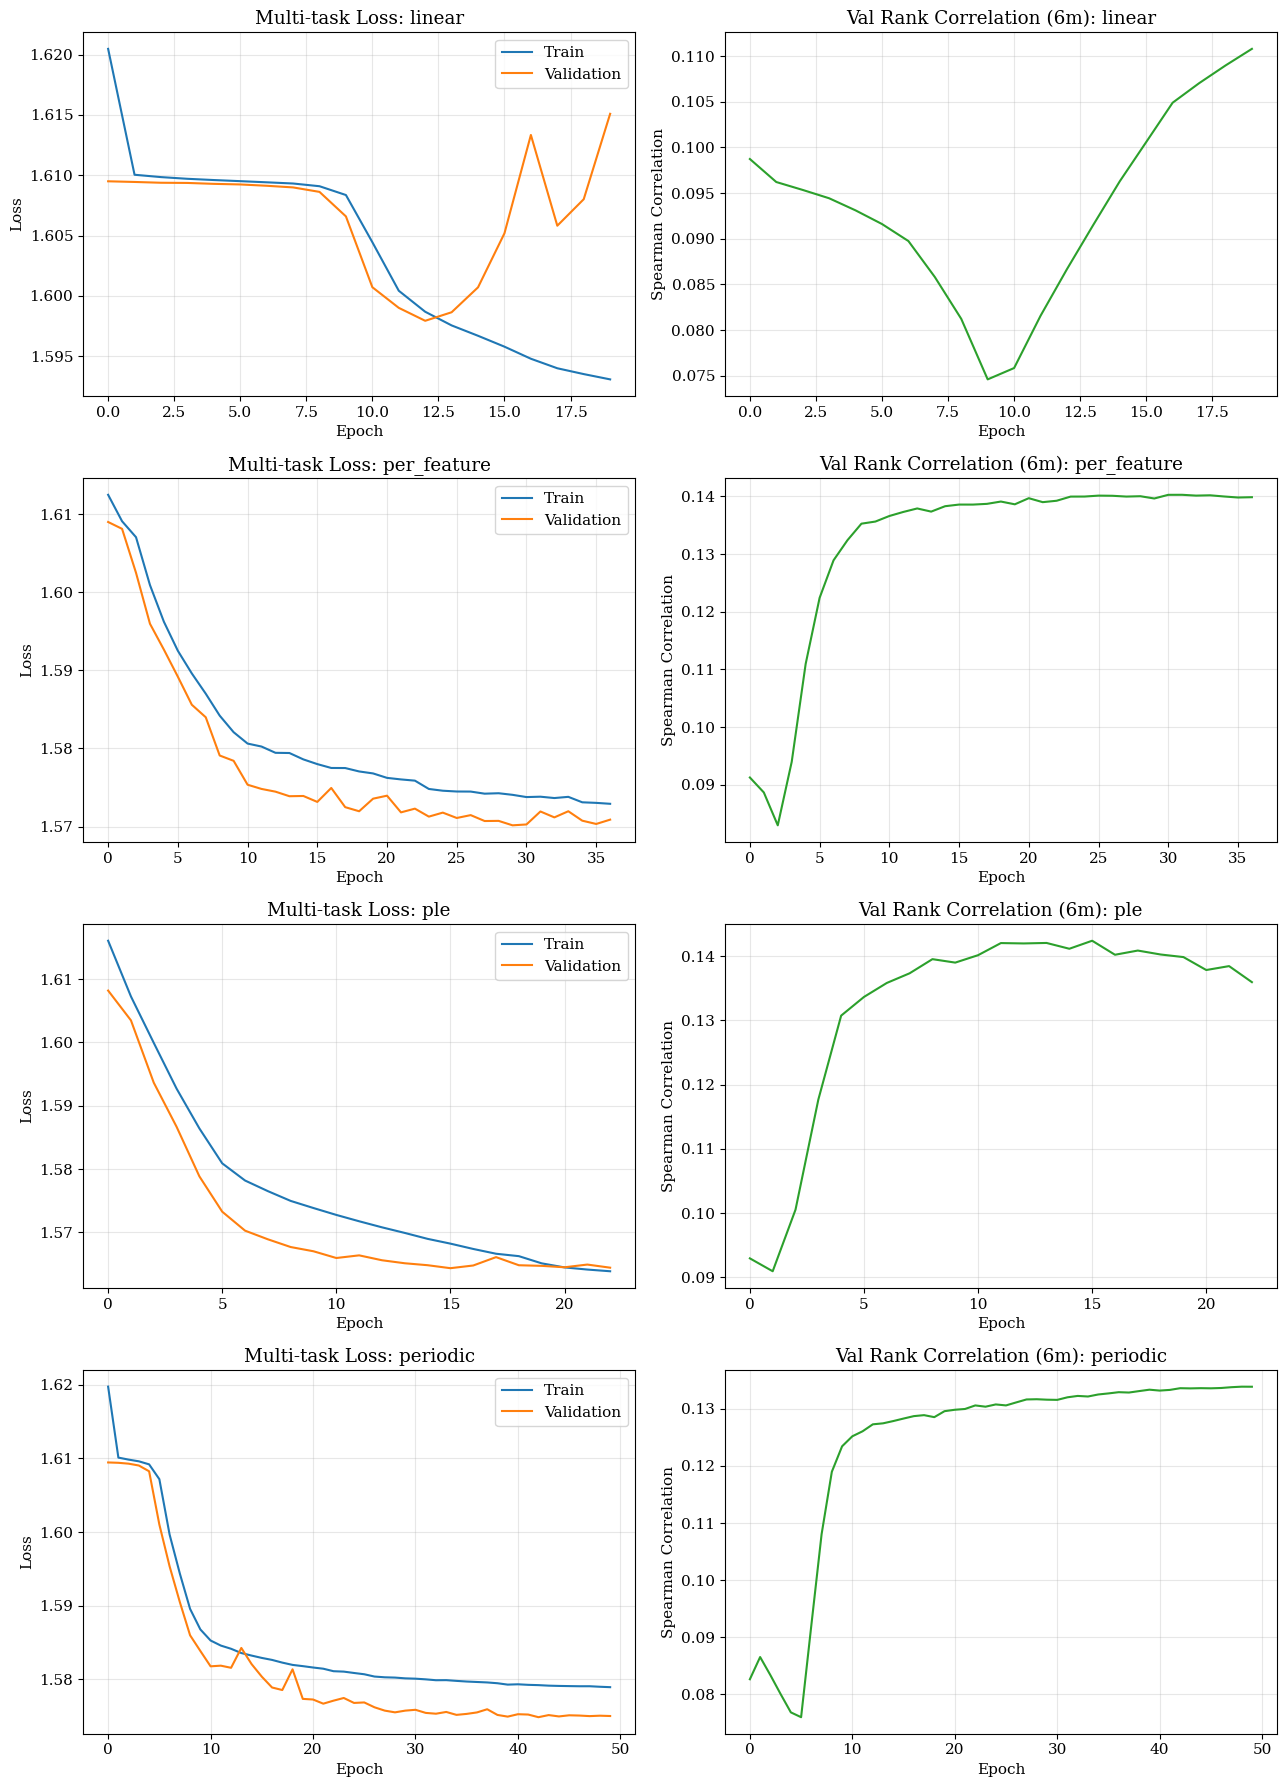

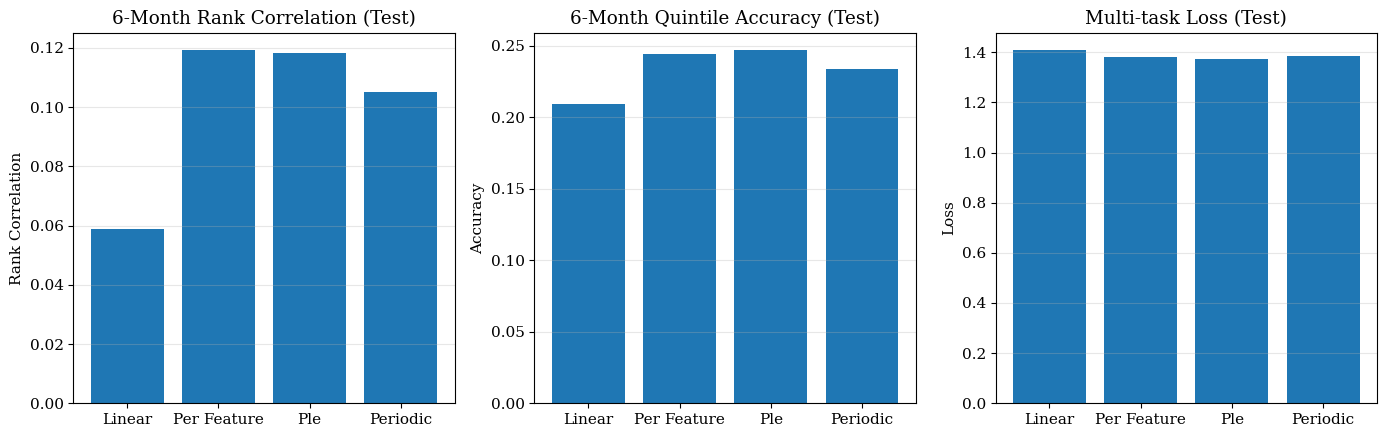

In [21]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.size"] = 11


def plot_training_curves(all_results):
	n_variants = len(all_results)
	fig, axes = plt.subplots(n_variants, 2, figsize = (13, 4.5 * n_variants))
	if n_variants == 1:
		axes = axes.reshape(1, -1)

	for row, (variant, res) in enumerate(all_results.items()):
		history = res["history"]

		axes[row, 0].plot(history["train_loss"], label = "Train", linewidth = 1.5)
		axes[row, 0].plot(history["val_loss"], label = "Validation", linewidth = 1.5)
		axes[row, 0].set_xlabel("Epoch")
		axes[row, 0].set_ylabel("Loss")
		axes[row, 0].set_title(f"Multi-task Loss: {variant}")
		axes[row, 0].legend()
		axes[row, 0].grid(alpha = 0.3)

		axes[row, 1].plot(history["val_corr_6m"], linewidth = 1.5, color = "tab:green")
		axes[row, 1].set_xlabel("Epoch")
		axes[row, 1].set_ylabel("Spearman Correlation")
		axes[row, 1].set_title(f"Val Rank Correlation (6m): {variant}")
		axes[row, 1].grid(alpha = 0.3)

	plt.tight_layout()
	plt.show()


def plot_variant_comparison(all_results):
	variants = list(all_results.keys())
	corr_6m = [all_results[v]["test_metrics"]["rank_corr"]["target_6m"] for v in variants]
	acc_6m = [all_results[v]["test_metrics"]["accuracy"]["target_6m"] for v in variants]
	losses = [all_results[v]["test_metrics"]["loss"] for v in variants]

	fig, axes = plt.subplots(1, 3, figsize = (14, 4.5))
	labels = [v.replace("_", " ").title() for v in variants]

	axes[0].bar(labels, corr_6m)
	axes[0].set_ylabel("Rank Correlation")
	axes[0].set_title("6-Month Rank Correlation (Test)")
	axes[0].grid(axis = "y", alpha = 0.3)

	axes[1].bar(labels, acc_6m)
	axes[1].set_ylabel("Accuracy")
	axes[1].set_title("6-Month Quintile Accuracy (Test)")
	axes[1].grid(axis = "y", alpha = 0.3)

	axes[2].bar(labels, losses)
	axes[2].set_ylabel("Loss")
	axes[2].set_title("Multi-task Loss (Test)")
	axes[2].grid(axis = "y", alpha = 0.3)

	plt.tight_layout()
	plt.show()


plot_training_curves(all_results)
plot_variant_comparison(all_results)

## 11. Portfolio Simulation (Best Variant)

In [25]:
@torch.no_grad()
def portfolio_simulation(model, dataset, config, rebalance_freq = 6, transaction_cost_bps = 25):
	model.eval()
	portfolio_returns = []
	prev_holdings = set()

	for idx in range(0, len(dataset), rebalance_freq):
		batch = dataset[idx]
		k0 = batch["k0"].to(device, non_blocking = True)
		k1 = batch["k1"].to(device, non_blocking = True)
		miss = batch["miss"].to(device, non_blocking = True)

		_, logits_6m, _, _ = model(k0, k1, miss)

		probs = F.softmax(logits_6m, dim = -1)
		quintile_idx = torch.arange(config.n_classes, device = device, dtype = torch.float32)
		scores = (probs * quintile_idx.unsqueeze(0)).sum(dim = -1)

		n_firms = scores.shape[0]
		cutoff = int(0.8 * n_firms)
		_, top_indices = scores.topk(n_firms - cutoff)
		top_set = set(top_indices.cpu().numpy().tolist())

		n_selected = len(top_set)
		if n_selected == 0:
			portfolio_returns.append(0.0)
			prev_holdings = top_set
			continue

		new_holdings = top_set - prev_holdings
		exited_holdings = prev_holdings - top_set
		turnover = (len(new_holdings) + len(exited_holdings)) / max(n_selected, 1)
		tc = turnover * transaction_cost_bps / 10000.0

		top_scores = scores[top_indices]
		top_weights = F.softmax(top_scores, dim = 0)

		raw_returns = batch["raw_targets"]["target_6m"]
		target_labels = batch["targets"]["target_6m"]
		weighted_return = 0.0
		for i, firm_idx in enumerate(top_indices.cpu().numpy()):
			if target_labels[firm_idx] >= 0:
				weighted_return += top_weights[i].item() * raw_returns[firm_idx].item()

		portfolio_returns.append(weighted_return - tc)
		prev_holdings = top_set

	return np.array(portfolio_returns)


@torch.no_grad()
def portfolio_simulation_long_short(model, dataset, config, rebalance_freq = 6, transaction_cost_bps = 25):
	model.eval()
	portfolio_returns = []
	prev_long = set()
	prev_short = set()

	for idx in range(0, len(dataset), rebalance_freq):
		batch = dataset[idx]
		k0 = batch["k0"].to(device, non_blocking = True)
		k1 = batch["k1"].to(device, non_blocking = True)
		miss = batch["miss"].to(device, non_blocking = True)

		_, logits_6m, _, _ = model(k0, k1, miss)

		probs = F.softmax(logits_6m, dim = -1)
		quintile_idx = torch.arange(config.n_classes, device = device, dtype = torch.float32)
		scores = (probs * quintile_idx.unsqueeze(0)).sum(dim = -1)

		n_firms = scores.shape[0]
		n_quintile = max(int(0.2 * n_firms), 1)

		# Top quintile (long) and bottom quintile (short)
		_, long_indices = scores.topk(n_quintile)
		_, short_indices = scores.topk(n_quintile, largest = False)

		long_set = set(long_indices.cpu().numpy().tolist())
		short_set = set(short_indices.cpu().numpy().tolist())

		# Transaction costs
		long_turnover = len(long_set - prev_long) + len(prev_long - long_set)
		short_turnover = len(short_set - prev_short) + len(prev_short - short_set)
		total_turnover = (long_turnover + short_turnover) / max(n_quintile, 1)
		tc = total_turnover * transaction_cost_bps / 10000.0

		raw_returns = batch["raw_targets"]["target_6m"]
		target_labels = batch["targets"]["target_6m"]

		# Score-weighted long leg
		long_scores = scores[long_indices]
		long_weights = F.softmax(long_scores, dim = 0)
		long_return = 0.0
		for i, firm_idx in enumerate(long_indices.cpu().numpy()):
			if target_labels[firm_idx] >= 0:
				long_return += long_weights[i].item() * raw_returns[firm_idx].item()

		# Score-weighted short leg (inverted scores for weighting)
		short_scores = -scores[short_indices]
		short_weights = F.softmax(short_scores, dim = 0)
		short_return = 0.0
		for i, firm_idx in enumerate(short_indices.cpu().numpy()):
			if target_labels[firm_idx] >= 0:
				short_return += short_weights[i].item() * raw_returns[firm_idx].item()

		# Long-short return: gain from longs, gain from shorts declining
		ls_return = long_return - short_return - tc
		portfolio_returns.append(ls_return)

		prev_long = long_set
		prev_short = short_set

	return np.array(portfolio_returns)


def compute_portfolio_metrics(returns, periods_per_year = 2):
	cum_return = (1 + returns).prod() - 1
	annualised_return = (1 + cum_return) ** (periods_per_year / max(len(returns), 1)) - 1
	annualised_vol = returns.std() * np.sqrt(periods_per_year)
	sharpe = annualised_return / max(annualised_vol, 1e-8)

	cum_wealth = np.cumprod(1 + returns)
	peak = np.maximum.accumulate(cum_wealth)
	drawdown = (peak - cum_wealth) / peak
	max_dd = drawdown.max()

	return {
		"cumulative_return": cum_return,
		"annualised_return": annualised_return,
		"annualised_vol": annualised_vol,
		"sharpe_ratio": sharpe,
		"max_drawdown": max_dd,
		"n_rebalances": len(returns),
	}

best_variant = max(all_results, key = lambda v: all_results[v]["test_metrics"]["rank_corr"]["target_6m"])
print(f"Best variant: {best_variant}")
print()

cfg.encoding_variant = best_variant
best_model = PortfolioTransformer(cfg).to(device)
best_model.load_state_dict(torch.load(cfg.results_dir / f"weights_{best_variant}.pt", weights_only = True))

test_ds = load_split(
	cfg.test_path, k0_feature_cols, k1_feature_cols,
	miss_flags, target_cols, cfg.n_classes, cfg.max_firms
)

lo_returns = portfolio_simulation(best_model, test_ds, cfg)
ls_returns = portfolio_simulation_long_short(best_model, test_ds, cfg)

print("Long-Only Portfolio:")
for k, v in compute_portfolio_metrics(lo_returns).items():
	print(f"  {k}: {v:.4f}")

print()
print("Long-Short Portfolio:")
for k, v in compute_portfolio_metrics(ls_returns).items():
	print(f"  {k}: {v:.4f}")

del best_model, test_ds
gc.collect()
if torch.cuda.is_available():
	torch.cuda.empty_cache()

Best variant: per_feature

Long-Only Portfolio:
  cumulative_return: 0.9978
  annualised_return: 0.1484
  annualised_vol: 0.1365
  sharpe_ratio: 1.0873
  max_drawdown: 0.0375
  n_rebalances: 10.0000

Long-Short Portfolio:
  cumulative_return: 0.9642
  annualised_return: 0.1446
  annualised_vol: 0.0703
  sharpe_ratio: 2.0561
  max_drawdown: 0.0265
  n_rebalances: 10.0000


## 12. Model Sanity Check

In [24]:
test_cfg = Config()
print("Parameter counts by variant:")
for variant in ["linear", "per_feature", "ple", "periodic"]:
	test_cfg.encoding_variant = variant
	m = PortfolioTransformer(test_cfg).to(device)
	n_test = 100
	k0_t = torch.randn(n_test, len(K0_CHARS), device = device)
	k1_t = torch.randn(n_test, len(K1_CHARS), 6, device = device)
	miss_t = torch.zeros(n_test, len(miss_flags), device = device)
	l3, l6, l12, attn = m(k0_t, k1_t, miss_t)
	n_p = sum(p.numel() for p in m.parameters() if p.requires_grad)
	print(f"  {variant:15s} | params: {n_p:>10,} | logits: {l6.shape} | attn: {attn[0].shape}")
	del m

gc.collect()
if torch.cuda.is_available():
	torch.cuda.empty_cache()
print()
print("All encoding variants produce correct output dimensions.")

Parameter counts by variant:
  linear          | params:    117,711 | logits: torch.Size([100, 5]) | attn: torch.Size([4, 100, 100])
  per_feature     | params:    117,711 | logits: torch.Size([100, 5]) | attn: torch.Size([4, 100, 100])
  ple             | params:    253,903 | logits: torch.Size([100, 5]) | attn: torch.Size([4, 100, 100])
  periodic        | params:    112,207 | logits: torch.Size([100, 5]) | attn: torch.Size([4, 100, 100])

All encoding variants produce correct output dimensions.
